## Effective radius

As the REFF_AERO variable showed little growth after Pinatubo, I'll try to see if there is another way to look at it, or if the modes are better to look at seperately.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal

In [32]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46501,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38515,Total threads: 4
Dashboard: http://127.0.0.1:38501/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:41639,


2025-12-16 15:51:07,516 - distributed.nanny - WARNING - Restarting worker
2025-12-16 15:58:50,266 - distributed.nanny - WARNING - Restarting worker
2025-12-16 15:58:50,268 - distributed.nanny - WARNING - Restarting worker
2025-12-16 15:59:00,138 - distributed.nanny - WARNING - Restarting worker
2025-12-16 15:59:00,145 - distributed.nanny - WARNING - Restarting worker
2025-12-16 15:59:00,150 - distributed.nanny - WARNING - Restarting worker
2025-12-16 16:01:58,606 - distributed.nanny - WARNING - Restarting worker
2025-12-16 16:07:48,110 - distributed.nanny - WARNING - Restarting worker


In [38]:
path_atm_22 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251125_pinatubo10Tg22_e01/atm/hist"
ds_22 = xr.open_mfdataset(f"{path_atm_22}/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01.cam.h0.*.nc", combine="by_coords", parallel=True)


In [39]:
path_atm_19_c =  "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251128_pinatubo10Tg19_e01/atm/hist"
ds_19_c = xr.open_mfdataset(f"{path_atm_19_c}/NHIST_tropstratchem_f09_tn14_20251128_Pinatubo10Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [41]:
path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [42]:
path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_19 = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.199*.nc", combine="by_coords", parallel=True)

In [43]:
path_atm_1825 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251204_pinatubo10Tg18_25_e01/atm/hist"
ds_1825 = xr.open_mfdataset(f"{path_atm_1825}/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fb8d82bff60>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [44]:
path_atm_1825_17tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251207_pinatubo17Tg18_25_e01/atm/hist"
ds_1825_17tg = xr.open_mfdataset(f"{path_atm_1825_17tg}/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [45]:
path_atm_1tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251210_pinatubo1Tg19_e01/atm/hist"
ds_1tg = xr.open_mfdataset(f"{path_atm_1tg}/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [46]:
client.close()

In [47]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])
ds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)

In [48]:
shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])
ds_1tg = ds_1tg.assign_coords(time=shifted_time)

In [49]:
lat_19 = ds_19["lat"]
weighted_lat_19 = np.cos(np.deg2rad(lat_19))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))
lat_1825_17tg = ds_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))
lat_1tg = ds_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))

In [50]:
lev_19 = ds_19["lev"]
weighted_lev_19 = np.cos(np.deg2rad(lev_19))
lev_19_c = ds_19_c["lev"]
weighted_lev_19_c = np.cos(np.deg2rad(lev_19_c))
lev_22 = ds_22["lev"]
weighted_lev_22 = np.cos(np.deg2rad(lev_22))
lev_24 = ds_24["lev"]
weighted_lev_24 = np.cos(np.deg2rad(lev_24))
lev_1825 = ds_1825["lev"]
weighted_lev_1825 = np.cos(np.deg2rad(lev_1825))
lev_1825_17tg = ds_1825_17tg["lev"]
weighted_lev_1825_17tg = np.cos(np.deg2rad(lev_1825_17tg))
lev_1tg = ds_1tg["lev"]
weighted_lev_1tg = np.cos(np.deg2rad(lev_1tg))

In [51]:
tropopause_19 = ds_19["TROP_P"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
p_lev_19 = tropopause_19 * 0.01
tropopause_19_c = ds_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
p_lev_19_c = tropopause_19_c * 0.01
tropopause_22 = ds_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
p_lev_22 = tropopause_22 * 0.01
tropopause_24 = ds_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
p_lev_24 = tropopause_24 * 0.01
tropopause_1825 = ds_1825["TROP_P"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
p_lev_1825 = tropopause_1825 * 0.01
tropopause_1825_17tg = ds_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
p_lev_1825_17tg = tropopause_1825_17tg * 0.01
tropopause_1tg = ds_1tg["TROP_P"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
p_lev_1tg = tropopause_1tg * 0.01

In [52]:
def compute_SReff(ds, p_lev=None, p_lev_lower=None, p_lev_upper=None,
                  lat_range=None, lon_range=None,
                  weighted_lat=None, weighted_lev=None,
                  cm_to_mym=10000):
    
    da = ds["REFF_AERO"]
    
    if p_lev is not None:
        da = da.sel(lev = p_lev, method="nearest")
    elif p_lev_lower is not None and p_lev_upper is not None:
        da = da.where((da["lev"] >= p_lev_lower) & (da["lev"] <= p_lev_upper))
    elif p_lev_upper is not None:
        da = da.where(da["lev"] < p_lev_upper)
    
    if lat_range:
        da = da.sel(lat=slice(*lat_range))
    if lon_range:
        da = da.sel(lon=slice(*lon_range))
    
    da = da.weighted(weighted_lat).mean(dim=["lat","lon"]) * cm_to_mym
    da = da.weighted(weighted_lev).mean(dim="lev")
    
    return da


Text(0.5, 1.0, 'Stratospheric effective radius (global mean)')

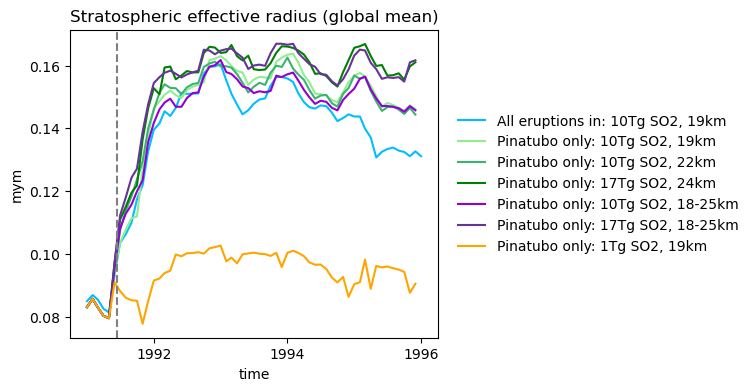

In [21]:
SReff = compute_SReff(ds_19, p_lev_upper = p_lev_19, weighted_lat=weighted_lat_19, weighted_lev=weighted_lev_19)
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c = compute_SReff(ds_19_c, p_lev_upper = p_lev_19_c, weighted_lat=weighted_lat_19_c, weighted_lev=weighted_lev_19_c)
SReff_22 = compute_SReff(ds_22, p_lev_upper=p_lev_22, weighted_lat=weighted_lat_22, weighted_lev=weighted_lev_22)
SReff_24 = compute_SReff(ds_24, p_lev_upper=p_lev_24, weighted_lat=weighted_lat_24, weighted_lev=weighted_lev_24)
SReff_1825 = compute_SReff(ds_1825, p_lev_upper=p_lev_1825, weighted_lat=weighted_lat_1825, weighted_lev=weighted_lev_1825)
SReff_1825_17tg = compute_SReff(ds_1825_17tg, p_lev_upper=p_lev_1825_17tg, weighted_lat=weighted_lat_1825_17tg, weighted_lev=weighted_lev_1825_17tg)
SReff_1tg = compute_SReff(ds_1tg, p_lev_upper=p_lev_1tg, weighted_lat=weighted_lat_1tg, weighted_lev=weighted_lev_1tg)

fig, ax = plt.subplots(figsize=(7, 4))
SReff.plot(ax=ax, color="deepskyblue", label="All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(ax=ax, color="lightgreen", label="Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(ax=ax, color="mediumseagreen", label="Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(ax=ax, color="green", label="Pinatubo only: 17Tg SO2, 24km")
SReff_1825.plot(ax=ax, color="darkviolet", label="Pinatubo only: 10Tg SO2, 18-25km")
SReff_1825_17tg.plot(ax=ax, color="rebeccapurple", label="Pinatubo only: 17Tg SO2, 18-25km")
SReff_1tg.plot(ax=ax, color="orange", label="Pinatubo only: 1Tg SO2, 19km")

tline = cftime.DatetimeNoLeap(1991, 6, 15)
ax.axvline(tline, color="gray", linestyle="--")

fig.subplots_adjust(right=0.65)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
ax.set_ylabel("mym")
ax.set_title("Stratospheric effective radius (global mean)")

Text(0.5, 1.0, 'Stratospheric effective radius (Tropics)')

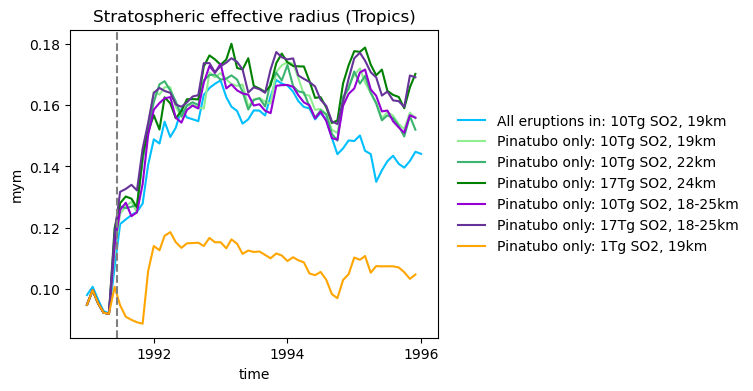

In [22]:
SReff = compute_SReff(ds_19, p_lev_upper = p_lev_19, weighted_lat=weighted_lat_19, weighted_lev=weighted_lev_19, lat_range=(-20,20))
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c = compute_SReff(ds_19_c, p_lev_upper = p_lev_19_c, weighted_lat=weighted_lat_19_c, weighted_lev=weighted_lev_19_c, lat_range=(-20,20))
SReff_22 = compute_SReff(ds_22, p_lev_upper=p_lev_22, weighted_lat=weighted_lat_22, weighted_lev=weighted_lev_22, lat_range=(-20,20))
SReff_24 = compute_SReff(ds_24, p_lev_upper=p_lev_24, weighted_lat=weighted_lat_24, weighted_lev=weighted_lev_24, lat_range=(-20,20))
SReff_1825 = compute_SReff(ds_1825, p_lev_upper=p_lev_1825, weighted_lat=weighted_lat_1825, weighted_lev=weighted_lev_1825, lat_range=(-20,20))
SReff_1825_17tg = compute_SReff(ds_1825_17tg, p_lev_upper=p_lev_1825_17tg, weighted_lat=weighted_lat_1825_17tg, weighted_lev=weighted_lev_1825_17tg, lat_range=(-20,20))
SReff_1tg = compute_SReff(ds_1tg, p_lev_upper=p_lev_1tg, weighted_lat=weighted_lat_1tg, weighted_lev=weighted_lev_1tg, lat_range=(-20,20))

fig, ax = plt.subplots(figsize=(7, 4))
SReff.plot(ax=ax, color="deepskyblue", label="All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(ax=ax, color="lightgreen", label="Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(ax=ax, color="mediumseagreen", label="Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(ax=ax, color="green", label="Pinatubo only: 17Tg SO2, 24km")
SReff_1825.plot(ax=ax, color="darkviolet", label="Pinatubo only: 10Tg SO2, 18-25km")
SReff_1825_17tg.plot(ax=ax, color="rebeccapurple", label="Pinatubo only: 17Tg SO2, 18-25km")
SReff_1tg.plot(ax=ax, color="orange", label="Pinatubo only: 1Tg SO2, 19km")

tline = cftime.DatetimeNoLeap(1991, 6, 15)
ax.axvline(tline, color="gray", linestyle="--")

fig.subplots_adjust(right=0.65)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
ax.set_ylabel("mym")
ax.set_title("Stratospheric effective radius (Tropics)")

Text(0.5, 1.0, 'Stratospheric effective radius (Equator,  lev ~64hPa)')

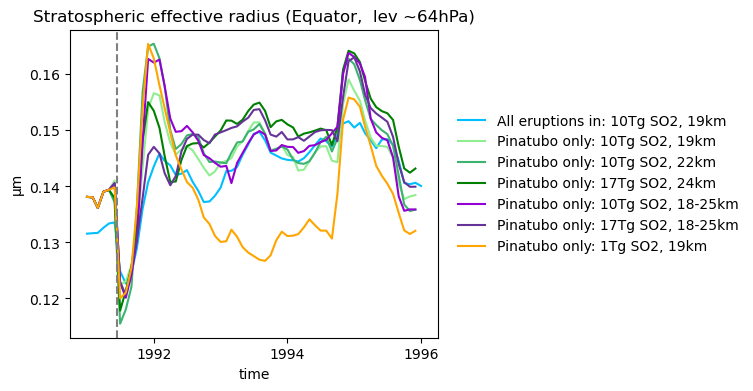

In [55]:
plev = 64
p_lev_l = 50
p_lev_u = 20
SReff = compute_SReff(ds_19, p_lev=plev, weighted_lat=weighted_lat_19, weighted_lev=weighted_lev_19, lat_range=(-5,5))
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c = compute_SReff(ds_19_c,  p_lev=plev, weighted_lat=weighted_lat_19_c, weighted_lev=weighted_lev_19_c, lat_range=(-5,5))
SReff_22 = compute_SReff(ds_22,  p_lev=plev, weighted_lat=weighted_lat_22, weighted_lev=weighted_lev_22, lat_range=(-5,5))
SReff_24 = compute_SReff(ds_24, p_lev=plev, weighted_lat=weighted_lat_24, weighted_lev=weighted_lev_24, lat_range=(-5,5))
SReff_1825 = compute_SReff(ds_1825, p_lev=plev, weighted_lat=weighted_lat_1825, weighted_lev=weighted_lev_1825, lat_range=(-5,5))
SReff_1825_17tg = compute_SReff(ds_1825_17tg, p_lev=plev,weighted_lat=weighted_lat_1825_17tg, weighted_lev=weighted_lev_1825_17tg, lat_range=(-5,5))
SReff_1tg = compute_SReff(ds_1tg, p_lev=plev, weighted_lat=weighted_lat_1tg, weighted_lev=weighted_lev_1tg, lat_range=(-5,5))


fig, ax = plt.subplots(figsize=(7, 4))
SReff.plot(ax=ax, color="deepskyblue", label="All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(ax=ax, color="lightgreen", label="Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(ax=ax, color="mediumseagreen", label="Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(ax=ax, color="green", label="Pinatubo only: 17Tg SO2, 24km")
SReff_1825.plot(ax=ax, color="darkviolet", label="Pinatubo only: 10Tg SO2, 18-25km")
SReff_1825_17tg.plot(ax=ax, color="rebeccapurple", label="Pinatubo only: 17Tg SO2, 18-25km")
SReff_1tg.plot(ax=ax, color="orange", label="Pinatubo only: 1Tg SO2, 19km")

tline = cftime.DatetimeNoLeap(1991, 6, 15)
ax.axvline(tline, color="gray", linestyle="--")

fig.subplots_adjust(right=0.65)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
ax.set_ylabel("µm")
ax.set_title(f"Stratospheric effective radius (Equator,  lev ~{plev}hPa)")


Text(0.5, 1.0, 'Stratospheric effective radius (Laramie, lev ~64hPa)')

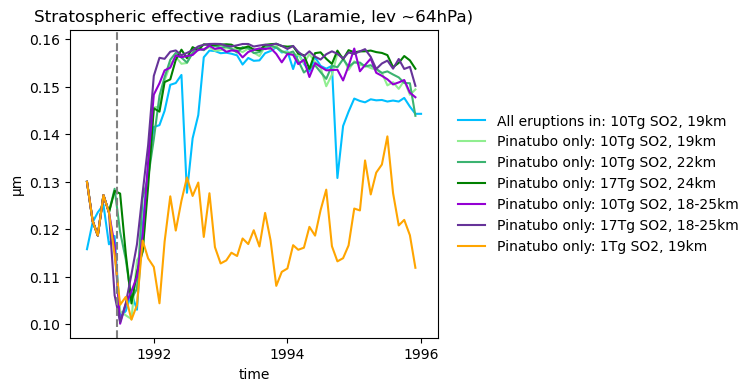

In [54]:
cm_to_mym = 10000
p_lev_l = 130
p_lev_u = 10
plev = 64
SReff = compute_SReff(ds_19, p_lev=plev, weighted_lat=weighted_lat_19, weighted_lev=weighted_lev_19, lat_range=(40,43), lon_range=(105, 106.5))
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c = compute_SReff(ds_19_c,  p_lev=plev, weighted_lat=weighted_lat_19_c, weighted_lev=weighted_lev_19_c, lat_range=(40,43), lon_range=(105, 106.5))
SReff_22 = compute_SReff(ds_22,  p_lev=plev, weighted_lat=weighted_lat_22, weighted_lev=weighted_lev_22, lat_range=(40,43), lon_range=(105, 106.5))
SReff_24 = compute_SReff(ds_24, p_lev=plev, weighted_lat=weighted_lat_24, weighted_lev=weighted_lev_24, lat_range=(40,43), lon_range=(105, 106.5))
SReff_1825 = compute_SReff(ds_1825,  p_lev=plev, weighted_lat=weighted_lat_1825, weighted_lev=weighted_lev_1825, lat_range=(40,43), lon_range=(105, 106.5))
SReff_1825_17tg = compute_SReff(ds_1825_17tg,  p_lev=plev, weighted_lat=weighted_lat_1825_17tg, weighted_lev=weighted_lev_1825_17tg, lat_range=(40,43), lon_range=(105, 106.5))
SReff_1tg = compute_SReff(ds_1tg,  p_lev=plev, weighted_lat=weighted_lat_1tg, weighted_lev=weighted_lev_1tg, lat_range=(40,43), lon_range=(105, 106.5))

fig, ax = plt.subplots(figsize=(7, 4))
SReff.plot(ax=ax, color="deepskyblue", label="All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(ax=ax, color="lightgreen", label="Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(ax=ax, color="mediumseagreen", label="Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(ax=ax, color="green", label="Pinatubo only: 17Tg SO2, 24km")
SReff_1825.plot(ax=ax, color="darkviolet", label="Pinatubo only: 10Tg SO2, 18-25km")
SReff_1825_17tg.plot(ax=ax, color="rebeccapurple", label="Pinatubo only: 17Tg SO2, 18-25km")
SReff_1tg.plot(ax=ax, color="orange", label="Pinatubo only: 1Tg SO2, 19km")

tline = cftime.DatetimeNoLeap(1991, 6, 15)
ax.axvline(tline, color="gray", linestyle="--")

fig.subplots_adjust(right=0.65)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
ax.set_ylabel("µm")
ax.set_title(f"Stratospheric effective radius (Laramie, lev ~{plev}hPa)")

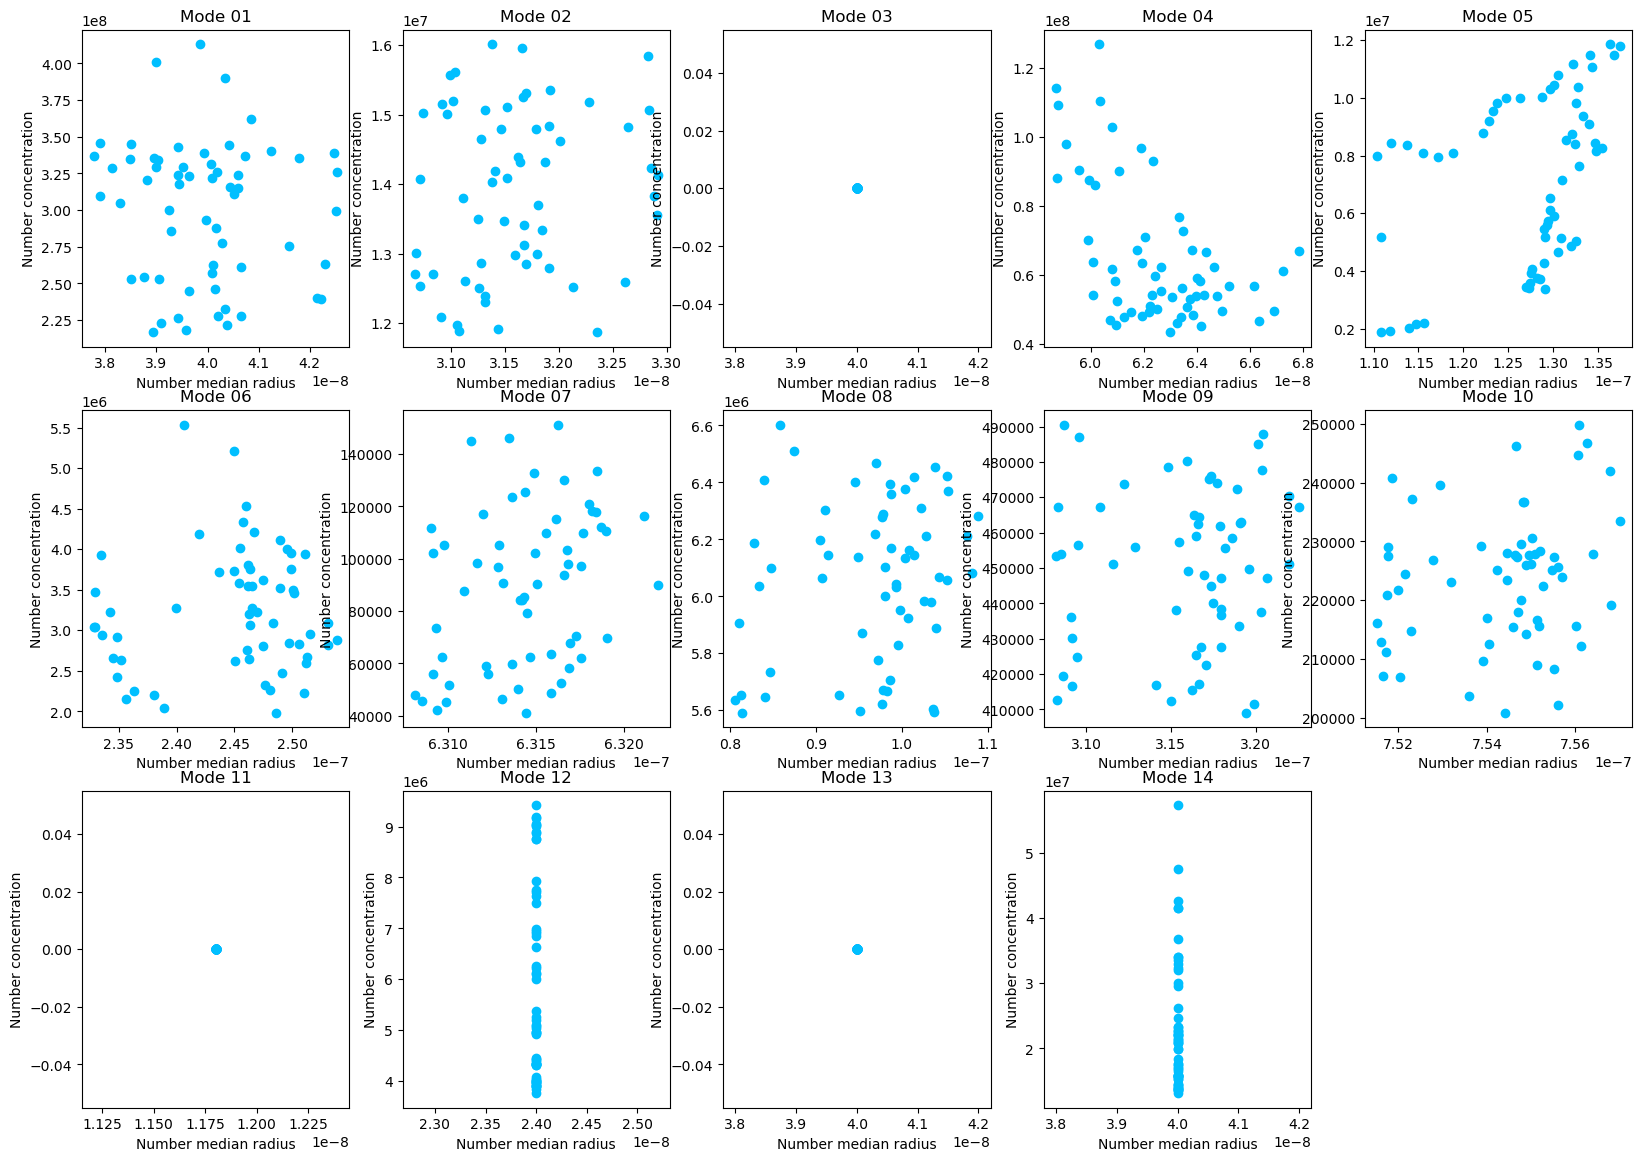

In [ ]:
# vars to use: NMR, SIGMA, NCONC, VCONC, NNAT_
mode_list = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12", "13", "14"]

fig, axes = plt.subplots(3, 5, figsize=(20, 14), sharex=False, sharey=False)
axes = axes.flatten() 
for i, mode in enumerate(mode_list):
    nmr_var = f"NMR{mode}"
    nconc_var = f"NCONC{mode}"
    
    nmr = ds_19_c[nmr_var].weighted(weighted_lat_19_c).mean(dim=["lat","lon","lev"])
    nconc = ds_19_c[nconc_var].weighted(weighted_lat_19_c).mean(dim=["lat","lon","lev"])
    
    axes[i].scatter(nmr, nconc, color="deepskyblue")
    axes[i].set_xlabel("Number median radius")
    axes[i].set_ylabel("Number concentration")
    axes[i].set_title(f"Mode {mode}")

for j in range(i+1, 3*5):
    fig.delaxes(axes[j])

plt.show()

## With Observations

In [ ]:
path_obs = "/nird/datapeak/NS1004K/elihho/obs_pinatubo/dataset/Observation"
sageii_tropreff = pd.read_csv(f"{path_obs}/sageii_tropical_reff.txt", delim_whitespace=True, header=0,  index_col=0)
start = pd.Timestamp("1991-01-01")
months_sageii = [int(c) for c in sageii_tropreff.columns]
dates_sageii = [start + pd.DateOffset(months=m) for m in months_sageii]
sageii_tropreff.columns = dates_sageii

/tmp/ipykernel_4117293/1079825040.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sageii_tropreff = pd.read_csv(f"{path_obs}/sageii_tropical_reff.txt", delim_whitespace=True, header=0,  index_col=0)


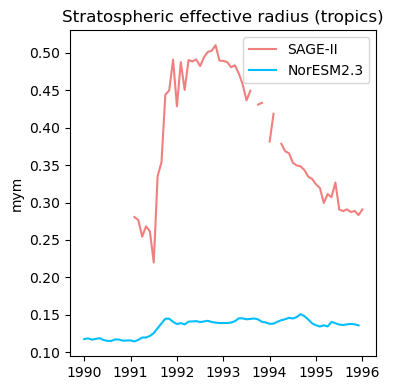

In [ ]:
strat_reff_sageii = sageii_tropreff.loc["Strat_mean_sad_weighted"].astype(float)
cm_to_mym = 10000

SReff = ds_19["REFF_AERO"].where(ds_19["REFF_AERO"]["lev"] <= p_lev_19)
SReff_trop = SReff.sel(lat = slice(-20,20))
SReff_trop = SReff_trop.weighted(weighted_lat_19).mean(dim=["lat", "lon", "lev"]) * cm_to_mym
SReff_trop = SReff_trop.sel(time=slice("1990-01-01", "1995-12-31"))

obs_time_sageii = np.array([t.year + (t.month-1)/12 for t in strat_reff_sageii.index])
time_years = np.array([t.year + (t.month-1)/12 for t in SReff_trop.time.values])

plt.figure(figsize=(4, 4))
plt.plot(obs_time_sageii, strat_reff_sageii, color = "lightcoral", label = "SAGE-II")
plt.plot(time_years, SReff_trop, color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("mym")
plt.title("Stratospheric effective radius (tropics)")
plt.legend()
plt.tight_layout()